# Compare Logged Models (MSE vs EWACF)

This notebook loads the latest models from the `Notebook_Presentation` experiment using MLflow and compares their predictions on the test set.


In [1]:
import matplotlib.pyplot as plt
import torch
import mlflow
from mlflow.tracking import MlflowClient
from tests.ablation_studies.data_loader import load_data
from tests.ablation_studies.config import DataMode
import tests.ablation_studies.model_setup  # Registers the models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"Device name: {torch.cuda.get_device_name(0)}")

Using device: cuda
Device name: NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
mlflow.set_tracking_uri("sqlite:///C:/Users/Luis/Documents/ML-AI-Projects/custom-lstm/notebooks/experiments/mlflow.db")
client = MlflowClient()

experiment = client.get_experiment_by_name("Notebook_Presentation")
if experiment is None:
    raise ValueError("Experiment 'Notebook_Presentation' not found.")


def get_latest_model(run_name):
    runs = client.search_runs(
        experiment_ids=[experiment.experiment_id], filter_string=f"tags.mlflow.runName = '{run_name}'", order_by=["start_time DESC"], max_results=1
    )
    if not runs:
        raise ValueError(f"Run '{run_name}' not found.")

    run_id = runs[0].info.run_id
    model_uri = f"runs:/{run_id}/model"
    print(f"Loading {run_name} from {model_uri}")
    return mlflow.pytorch.load_model(model_uri)


model_mse = get_latest_model("LSTM_Custom_Windowed_MSE")
model_ewacf = get_latest_model("LSTM_Custom_Windowed_EWACF")


Loading LSTM_Custom_Windowed_MSE from runs:/590ad29867274246b350debcb40ef1ab/model


Loading LSTM_Custom_Windowed_EWACF from runs:/8faced30cf3e4af5909c3ffef9531713/model


In [11]:
data_path = "C:/Users/Luis/Documents/ML-AI-Projects/custom-lstm/data/preprocessed/ethernet_traffic.csv"
data_dict, scaler = load_data(data_path, window_size=50)
mode_train = data_dict.train.get_by_mode(DataMode.WINDOWED)
mode_test = data_dict.test.get_by_mode(DataMode.WINDOWED)
mode_val = data_dict.val.get_by_mode(DataMode.WINDOWED)
X_train, y_train = mode_train.X, mode_train.Y
X_test, y_test = mode_test.X, mode_test.Y
X_val, y_val = mode_val.X, mode_val.Y

print(f"Train data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Val data shape: {X_val.shape}")


Train data shape: torch.Size([1, 2750, 50])
Test data shape: torch.Size([1, 550, 50])
Val data shape: torch.Size([1, 550, 50])


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_mse = model_mse.to(device)
model_ewacf = model_ewacf.to(device)
X_train = X_train.to(device)
y_train = y_train.to(device)

model_mse.eval()
with torch.no_grad():
    model_mse.reset_state()
    y_pred_mse, telemetry_mse = model_mse(X_train)

model_ewacf.eval()
with torch.no_grad():
    model_ewacf.reset_state()
    y_pred_ewacf, telemetry_ewacf = model_ewacf(X_train)

pred_mse = scaler.inverse_transform(y_pred_mse.detach().cpu().numpy().reshape(-1, 1))
pred_ewacf = scaler.inverse_transform(y_pred_ewacf.detach().cpu().numpy().reshape(-1, 1))
actual = scaler.inverse_transform(y_train.detach().cpu().numpy().reshape(-1, 1))


In [ ]:
error = torch.nn.MSELoss()
print(f"Error MSE Model: {error(y_pred_mse, y_test)}")
print(f"Error EWACF Model: {error(y_pred_ewacf, y_test)}")

Error MSE Model: 0.6672118306159973
Error EWACF Model: 0.7148706316947937


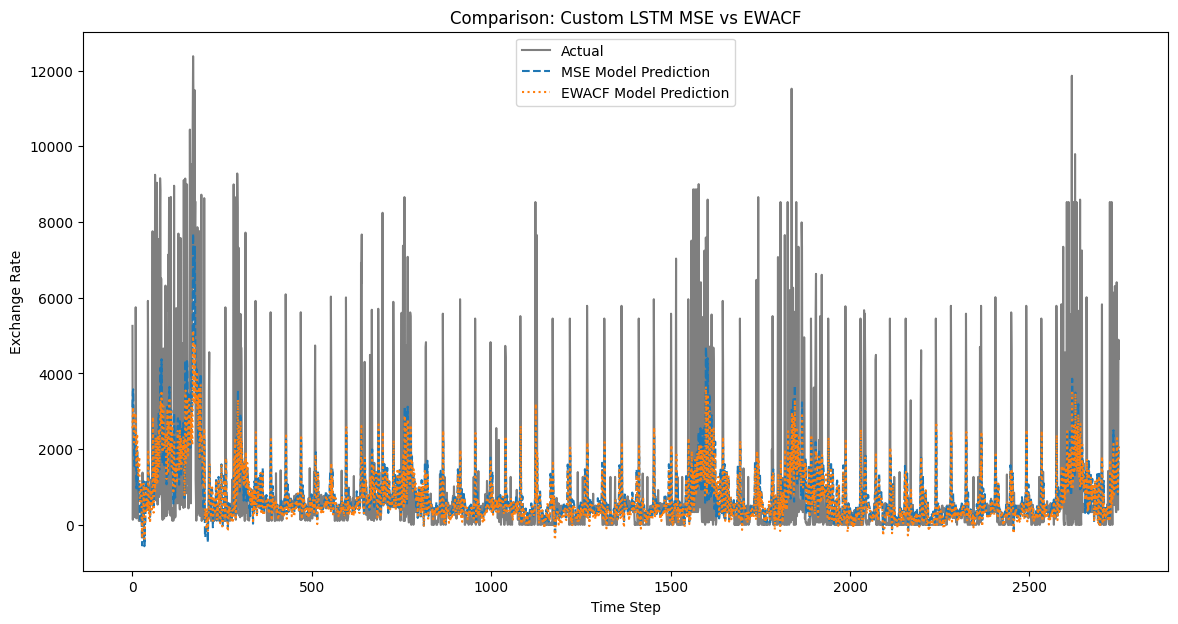

In [15]:
plt.figure(figsize=(14, 7))
plt.plot(actual, label="Actual", color="black", alpha=0.5)
plt.plot(pred_mse, label="MSE Model Prediction", linestyle="--")
plt.plot(pred_ewacf, label="EWACF Model Prediction", linestyle=":")
plt.title("Comparison: Custom LSTM MSE vs EWACF")
plt.xlabel("Time Step")
plt.ylabel("Exchange Rate")
plt.legend()
plt.show()


### Forget gates

In [16]:
fg_ewacf = telemetry_ewacf.forget_gates.detach().cpu().flatten().numpy()
fg_mse = telemetry_mse.forget_gates.detach().cpu().flatten().numpy()

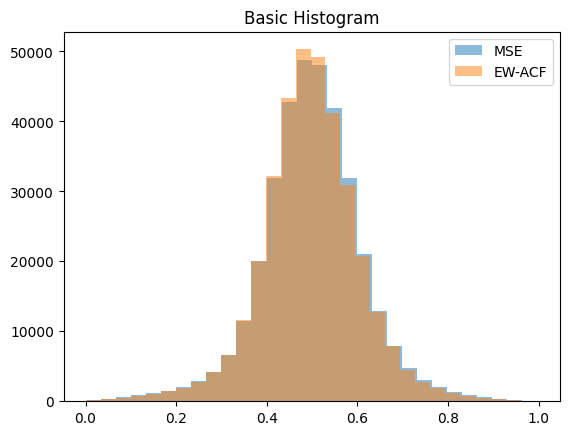

In [17]:
plt.hist(fg_mse, bins=30, alpha=0.5, label='MSE')
plt.hist(fg_ewacf, bins=30, alpha=0.5, label='EW-ACF')
plt.title("Basic Histogram")
plt.legend()
plt.show()

In [28]:
from scipy.stats import wasserstein_distance

distance = wasserstein_distance(fg_ewacf, fg_mse)
print(distance)

0.014585416488182752
